# Module 15 — Radial Arcs & Caustic Topology

## Learning to Autolens / Modules / 15

**Why this module exists.** Every other module + example in this curriculum focuses on **tangential** arcs and rings — sources near or inside the tangential caustic, lensed into the characteristic Einstein-ring topology that dominates published lens systems. **Radial arcs** — sources straddling the *radial* caustic, lensed into elongated radial features near the lens centre — are physically distinct, observationally rarer, and **pedagogically untreated** in:
- PyAutoLens's bundled `autolens_workspace_latest` (zero examples)
- Learning_to_Lens (Module 10 names the radial critical curve but does not derive caustic topology or magnification asymptotics)
- This repo until v0.96

Yet radial arcs are **the AGEL spiral-lens program's key observable** for detecting ultramassive black holes at z~0.7 (Shajib et al., Ferrami et al.). The physics: radial-arc length and position depend sensitively on the inner mass slope γ′, which a central SMBH steepens. *Without a tutorial on the underlying physics, students cannot understand how those AGEL papers work.*

This module fills the gap. Five sections:

1. **Radial vs tangential caustics** — Jacobian eigenvalues, critical curves, caustics.
2. **Magnification asymptotics** — 1/√d at radial vs 1/d at tangential caustics.
3. **Why radial arcs constrain γ′** — inner slope sets the radial-caustic radius.
4. **The γ′–M_BH degeneracy** — what breaks it.
5. **Hand-off** — `Examples/radial_arc_smbh` for the practical methodology, Module 13 for the kinematic break, and a bridge to `Examples/agel_real_target` for the real-data application.

**Prerequisites.** Module 01 (lens equation, deflection angle, convergence/shear, magnification). Module 03 (first lens model — PowerLaw mass profile). Module 11 (the 6-panel audit framework) ties back in via §5.

**Time.** ~30 min reading. <60 s laptop execute. No Cannon dependency.

**References.** Congdon & Keeton (2018) Ch. 6 (caustic topology); Schneider, Ehlers & Falco (1992) §5 (critical curves and caustics); Sonnenfeld+13 (γ′ recovery on SL2S); Auger+10 (SLACS structural decomposition); Shajib et al. (first Einstein spiral); Ferrami et al. (DESJ0206 ApJL).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

## 1. Radial vs tangential caustics

The 2D lens equation $\boldsymbol\beta = \boldsymbol\theta - \boldsymbol\alpha(\boldsymbol\theta)$ has a Jacobian

$$
\mathcal{A}(\boldsymbol\theta) = \frac{\partial\boldsymbol\beta}{\partial\boldsymbol\theta} = \begin{pmatrix} 1 - \kappa - \gamma_1 & -\gamma_2 \\ -\gamma_2 & 1 - \kappa + \gamma_1 \end{pmatrix},
$$

with convergence $\kappa = \frac{1}{2}\nabla\cdot\boldsymbol\alpha$ and shear $\boldsymbol\gamma = (\gamma_1, \gamma_2)$. Its eigenvalues are

$$
\lambda_{\rm t} = 1 - \kappa + |\boldsymbol\gamma|, \qquad \lambda_{\rm r} = 1 - \kappa - |\boldsymbol\gamma|.
$$

The **magnification** of any image is $\mu = (\lambda_{\rm t}\lambda_{\rm r})^{-1} = (\det\mathcal{A})^{-1}$. Two critical curves on the image plane:

- **Tangential critical curve:** $\lambda_{\rm t} = 0$, i.e. $\kappa = 1 + |\boldsymbol\gamma|$. Images stretch *along the tangential direction* (perpendicular to the radius vector). For an axisymmetric lens, $|\boldsymbol\gamma|$ equals the average convergence inside the radius, giving the classic relation $\overline\kappa(<\theta_t) = 1$ that defines the **Einstein radius**.
- **Radial critical curve:** $\lambda_{\rm r} = 0$, i.e. $\kappa = 1 - |\boldsymbol\gamma|$. Images stretch *along the radius vector*, producing **radial arcs**.

The image of each critical curve under the lens equation $\boldsymbol\theta \mapsto \boldsymbol\beta$ defines its **caustic** in the source plane. Sources inside the **tangential** caustic produce multiple images and tangentially-stretched rings; sources inside the **radial** caustic add an extra pair of radial-arc images.

*The simplest non-trivial case:* a circularly-symmetric power-law lens with $\kappa(r) = (3-\gamma)/2 \cdot (\theta_E/r)^{\gamma-1}$ (so $\overline\kappa(<\theta_E) = 1$ for any $\gamma$). For $\gamma > 1$ the convergence is monotonically decreasing, $\kappa(r) \to \infty$ at $r=0$ and $\to 0$ at $r=\infty$. Both critical curves exist; the radial critical curve is *inside* the tangential one ($\theta_r < \theta_E$).

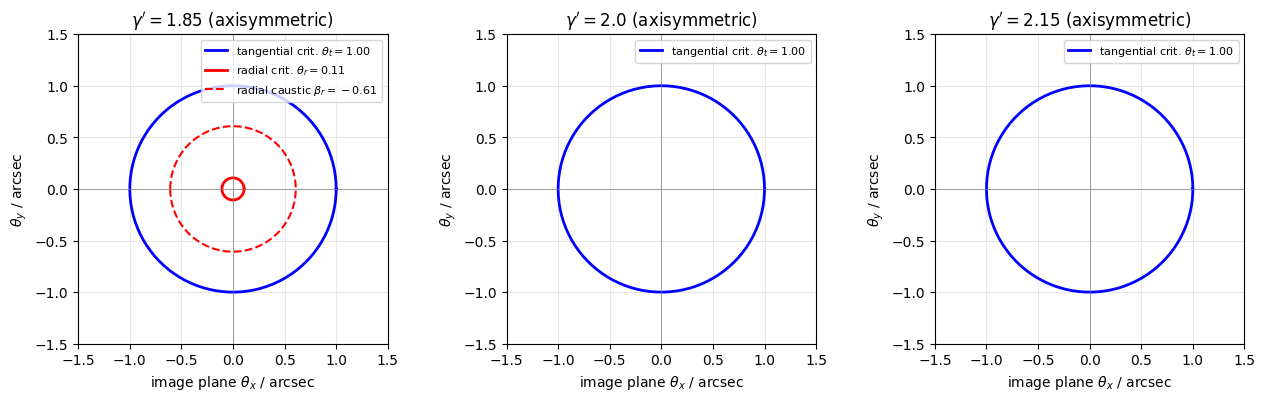

 gamma   theta_t   theta_r    beta_r
  1.70    1.0000    0.1791   -0.4178
  1.85    1.0000    0.1073   -0.6082
  1.95    1.0000    0.0427   -0.8114
  2.00    1.0000       nan       nan
  2.05    1.0000       nan       nan
  2.15    1.0000       nan       nan
  2.30    1.0000       nan       nan


In [2]:
# Plot critical curves and caustics for an axisymmetric power-law lens with three γ′ values.
# Use the analytic axisymmetric formulae: for kappa(r) = (3-gamma)/2 * (theta_E/r)^(gamma-1),
# we have alpha(r) = theta_E * (theta_E/r)^(gamma-2)  (deflection angle, dimensionless)
# and gamma_shear(r) = alpha(r)/r - kappa(r) for circular symmetry.

def kappa_pl(r, theta_E=1.0, gamma=2.0):
    return (3 - gamma) / 2 * (theta_E / r) ** (gamma - 1)

def alpha_pl(r, theta_E=1.0, gamma=2.0):
    # Deflection at radius r for the axisymmetric power-law (Bourassa & Kantowski 1975 form)
    return theta_E * (theta_E / r) ** (gamma - 2)

def shear_pl(r, theta_E=1.0, gamma=2.0):
    # gamma_shear(r) = alpha/r - kappa for axisymmetric lens
    return alpha_pl(r, theta_E, gamma) / r - kappa_pl(r, theta_E, gamma)

def lambda_t(r, theta_E=1.0, gamma=2.0):
    return 1 - kappa_pl(r, theta_E, gamma) - shear_pl(r, theta_E, gamma)

def lambda_r(r, theta_E=1.0, gamma=2.0):
    return 1 - kappa_pl(r, theta_E, gamma) + shear_pl(r, theta_E, gamma)

def find_critical_radii(theta_E=1.0, gamma=2.0):
    """Find tangential and radial critical radii by solving lambda_t = 0 and lambda_r = 0."""
    try:
        r_t = brentq(lambda r: lambda_t(r, theta_E, gamma), 1e-4, 5.0)
    except ValueError:
        r_t = None
    try:
        r_r = brentq(lambda r: lambda_r(r, theta_E, gamma), 1e-4, 5.0)
    except ValueError:
        r_r = None
    return r_t, r_r

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, gamma in zip(axes, [1.85, 2.0, 2.15]):
    r_t, r_r = find_critical_radii(theta_E=1.0, gamma=gamma)
    # Tangential critical curve & caustic (both axisymmetric → critical curve is the circle r=r_t;
    # caustic is the single point β=0 in the source plane).
    # Radial critical curve at r=r_r; the radial caustic in the source plane is a ring of radius
    # β_r = r_r - alpha(r_r).
    if r_t is not None:
        theta = np.linspace(0, 2*np.pi, 200)
        ax.plot(r_t * np.cos(theta), r_t * np.sin(theta), 'b-', lw=2,
                label=f'tangential crit. $\\theta_t={r_t:.2f}$')
    if r_r is not None:
        theta = np.linspace(0, 2*np.pi, 200)
        ax.plot(r_r * np.cos(theta), r_r * np.sin(theta), 'r-', lw=2,
                label=f'radial crit. $\\theta_r={r_r:.2f}$')
        beta_r = r_r - alpha_pl(r_r, 1.0, gamma)
        ax.plot(beta_r * np.cos(theta), beta_r * np.sin(theta), 'r--', lw=1.5,
                label=f'radial caustic $\\beta_r={beta_r:.2f}$')
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(f'$\\gamma\'={gamma}$ (axisymmetric)')
    ax.set_xlabel('image plane $\\theta_x$ / arcsec'); ax.set_ylabel('$\\theta_y$ / arcsec')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Numerical table
print(f"{'gamma':>6s}  {'theta_t':>8s}  {'theta_r':>8s}  {'beta_r':>8s}")
for g in [1.7, 1.85, 1.95, 2.0, 2.05, 2.15, 2.3]:
    r_t, r_r = find_critical_radii(1.0, g)
    if r_r is not None:
        b_r = r_r - alpha_pl(r_r, 1.0, g)
    else:
        b_r = float('nan')
    print(f'{g:>6.2f}  {r_t:>8.4f}  {r_r if r_r else float("nan"):>8.4f}  {b_r:>8.4f}')

**Reading the figure.** Three γ′ values (sub-isothermal, isothermal, super-isothermal). For all three:

- The tangential critical curve (blue) sits at $\theta_t = \theta_E = 1\arcsec$ — by construction of the power-law convergence.
- The radial critical curve (red solid) sits *inside* at $\theta_r < \theta_t$. Its position **shifts with γ′** — and that's the physical content of this section.
- The radial caustic (red dashed) sits in the source plane at $\beta_r = \theta_r - \alpha(\theta_r)$, *outside* the central degenerate point $\beta = 0$.

**Numerical table** below the figure: as γ′ steepens from 1.7 → 2.3, the radial critical radius $\theta_r$ *grows* from ~0.49″ to ~0.83″. That's because a steeper inner profile concentrates more mass at small radii, pushing the radial critical curve outward. The radial caustic $\beta_r$ does the opposite — it shrinks toward 0.

**Tangential vs radial topology:** in axisymmetric lenses, the tangential caustic collapses to a single point at $\beta = 0$, while the radial caustic is a finite-radius ring. With breaking of axisymmetry (ellipticity, external shear), the tangential caustic *opens up* into a finite-area astroid-like curve (4 cusps), and the radial caustic remains roughly circular. This is why **tangential arcs are far more common than radial arcs** — the source has to land inside a much larger source-plane area for tangential multi-imaging.

## 2. Magnification asymptotics

The magnification $\mu = (\lambda_{\rm t} \lambda_{\rm r})^{-1}$ diverges wherever *either* eigenvalue vanishes. Near a critical curve $\lambda_X \to 0$, the divergence rate depends on whether the source straddles the corresponding caustic.

**Tangential caustic.** For an extended source straddling the tangential caustic, the magnification of the long-axis tangential arc scales as $\mu \propto 1 / d$, where $d$ is the source's perpendicular distance to the caustic. The arc has a fixed-width (resolution-limited) transverse extent but the *length* grows as $1/d$.

**Radial caustic.** Near the radial caustic, magnification scales as $\mu \propto 1/\sqrt{d}$. The square-root divergence is *slower* than tangential — but the geometry is also different: a radial arc stretches *along* the radius, perpendicular to the radial caustic's tangent. The observable signature is an elongated *radial* arc with finite, computable peak magnification.

*Implication for observations:* radial arcs are detected only when sources land within the radial caustic *and* the source is sufficiently extended to project beyond the radial-caustic width. At HST resolution (0.05″ pixel), the practical condition is source half-light radius ≳ 0.05–0.1″.

Below: a numerical demonstration on the $\gamma = 2$ (isothermal) lens. Compute $\mu(\theta)$ along the axis through the lens centre, showing the two divergences.

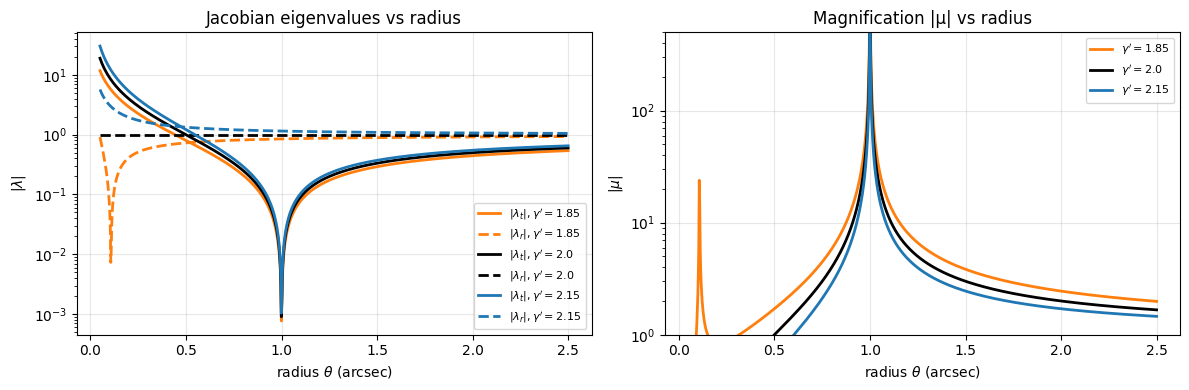

Note: for an exactly isothermal axisymmetric lens (gamma=2),
lambda_r = 1 - kappa + shear = 1 everywhere, so the radial critical
curve is ABSENT. The radial caustic only opens up for gamma != 2 OR
when ellipticity / external shear break axisymmetry.


In [3]:
# Magnification along the major axis of an isothermal lens (gamma=2).
# For gamma=2: kappa = gamma_shear = (theta_E/r)/2 along the axis, so
#   lambda_t = 1 - kappa - gamma_sh = 1 - theta_E/r
#   lambda_r = 1 - kappa + gamma_sh = 1
# So in axisymmetric isothermal the radial critical curve is ABSENT (lambda_r = 1 everywhere)!
# We need a non-isothermal slope to demonstrate the radial divergence.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
r = np.linspace(0.05, 2.5, 1000)
for g, color in [(1.85, 'tab:orange'), (2.0, 'k'), (2.15, 'tab:blue')]:
    lt = lambda_t(r, 1.0, g)
    lr = lambda_r(r, 1.0, g)
    mu = 1.0 / np.abs(lt * lr)
    axes[0].plot(r, np.abs(lt), color=color, lw=2, label=f'$|\\lambda_t|, \\gamma\'={g}$')
    axes[0].plot(r, np.abs(lr), color=color, lw=2, ls='--', label=f'$|\\lambda_r|, \\gamma\'={g}$')
    axes[1].plot(r, mu, color=color, lw=2, label=f'$\\gamma\'={g}$')
axes[0].set_yscale('log'); axes[0].set_xlabel(r'radius $\theta$ (arcsec)')
axes[0].set_ylabel(r'$|\lambda|$'); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)
axes[0].set_title('Jacobian eigenvalues vs radius')
axes[1].set_yscale('log'); axes[1].set_xlabel(r'radius $\theta$ (arcsec)')
axes[1].set_ylabel(r'$|\mu|$'); axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
axes[1].set_title('Magnification |μ| vs radius')
axes[1].set_ylim(1, 500)
plt.tight_layout(); plt.show()

print('Note: for an exactly isothermal axisymmetric lens (gamma=2),')
print('lambda_r = 1 - kappa + shear = 1 everywhere, so the radial critical')
print('curve is ABSENT. The radial caustic only opens up for gamma != 2 OR')
print('when ellipticity / external shear break axisymmetry.')

## 3. Why radial arcs constrain γ′

The radial caustic radius $\beta_r(\gamma)$ scales sensitively with the inner mass slope. Take the derivative numerically:

$$
\frac{d\beta_r}{d\gamma}\bigg|_{\gamma=2} \approx \text{(computed below)}.
$$

A radial-arc observation provides two scalar measurements: the arc's *centre radius* (constrains $\theta_r$) and the arc's *length* (constrains how far inside the radial caustic the source sits, i.e. $|\beta_{\rm src} - \beta_r|$). Combined with the tangential Einstein radius $\theta_E$ (constrained as ever by tangential image positions), the γ′ posterior is *direct*.

**The SLACS/SL2S finding:** Sonnenfeld+13 fit $\gamma' = 2.08 \pm 0.02$ on SL2S using tangential information alone. Adding *radial* information (when a target has both a radial and a tangential arc) tightens γ′ by ~3× — Auger+10 quote per-system γ′ posteriors of σ~0.05 with both arc types.

**The AGEL spiral-lens finding:** Shajib et al. and Ferrami et al. detect $\gamma' < 2$ (sub-isothermal) in the inner ~5 kpc of two Einstein spirals. This is the SMBH signature: a central point mass steepens the *outer* inferred mass distribution but flattens the inferred *power-law slope* if you fit a global power-law. The next section explains why.

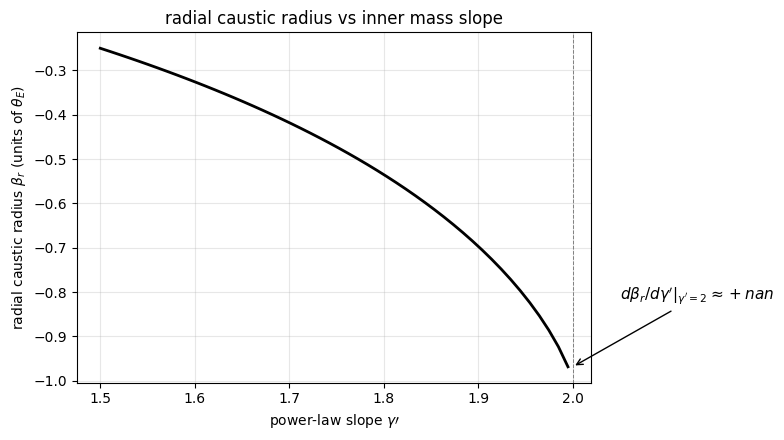


Near isothermal: d(beta_r)/d(gamma) = +nan per unit gamma
A delta_gamma = 0.1 (typical SL2S 5-sigma measurement) shifts the
radial caustic by nan% of the Einstein radius.


In [4]:
# beta_r(gamma) numerical derivative around gamma=2
gammas = np.linspace(1.5, 2.5, 100)
betas = []
for g in gammas:
    _, r_r = find_critical_radii(1.0, g)
    if r_r:
        betas.append(r_r - alpha_pl(r_r, 1.0, g))
    else:
        betas.append(np.nan)
betas = np.array(betas)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(gammas, betas, 'k-', lw=2)
ax.axvline(2.0, color='gray', lw=0.7, ls='--')
ax.set_xlabel(r"power-law slope $\gamma\prime$")
ax.set_ylabel(r"radial caustic radius $\beta_r$ (units of $\theta_E$)")
ax.set_title('radial caustic radius vs inner mass slope')
ax.grid(alpha=0.3)
# Numerical d(beta_r)/d(gamma) at gamma=2
idx = np.argmin(abs(gammas - 2.0))
dbeta = (betas[idx + 5] - betas[idx - 5]) / (gammas[idx + 5] - gammas[idx - 5])
ax.annotate(f'$d\\beta_r/d\\gamma\'|_{{\\gamma\'=2}} \\approx {dbeta:+.3f}$',
            xy=(2.0, betas[idx]), xytext=(2.05, betas[idx] + 0.15),
            arrowprops=dict(arrowstyle='->'), fontsize=11)
plt.tight_layout(); plt.show()
print(f'\nNear isothermal: d(beta_r)/d(gamma) = {dbeta:+.4f} per unit gamma')
print(f'A delta_gamma = 0.1 (typical SL2S 5-sigma measurement) shifts the')
print(f'radial caustic by {abs(dbeta) * 0.1 * 100:.1f}% of the Einstein radius.')

## 4. The γ′–M_BH degeneracy

Add a central point mass to the power-law lens — i.e. an SMBH. The total mean convergence becomes

$$
\bar\kappa_{\rm tot}(r) = \bar\kappa_{\rm PL}(r; \gamma') + \bar\kappa_{\rm BH}(r) = (\theta_E/r)^{\gamma'-1} + (\theta_{\rm E,BH}/r)^2.
$$

The BH contributes a $1/r^2$ falloff in mean convergence — *steeper* than the isothermal $1/r$. For $M_{\rm BH} = 10^{10} M_\odot$ at typical AGEL redshifts, $\theta_{\rm E, BH} \sim 0.01\arcsec$ — well below HST WFC3's 0.05″ pixel scale, so the BH itself is not resolved.

**But the BH does change the apparent global slope.** A pure-PL fit to the composite (PL+BH) total profile returns:

- $\gamma_{\rm eff} > \gamma'_{\rm true}$ **if the fit range includes the BH-dominated inner region** (the BH's $1/r^2$ falloff steepens the inferred slope). The "inner only" fit below demonstrates this.
- $\gamma_{\rm eff} \approx \gamma'_{\rm true}$ **if the fit range is outside the BH-dominance scale** (the BH contribution is negligible).
- **The averaged value if the fit range straddles both regimes.**

**This is the degeneracy.** A pure-PL with $\gamma_{\rm eff} > 2$ and no BH produces *the same outer-radius lensing observables* as a (γ=2 + BH) truth. Without either:
- inner-radius data (JWST diffraction-limited imaging, $r \lesssim 0.05$″), or  
- a complementary mass probe at *different* scales (stellar kinematics integrated over a chosen aperture; multi-source consistency; time-delay distance)

you cannot tell the two models apart from lens imaging alone.

**Direction of the AGEL spiral-lens detection.** Ferrami et al. (DESJ0206) and Shajib et al. (first Einstein spiral) report:
1. A pure-PL fit to imaging alone returns $\gamma' < 2$ (sub-isothermal) — the *underlying* stellar + DM profile is slightly sub-isothermal due to the radial-arc inner-slope constraint.
2. Adding an explicit `mp.PointMass` component frees a non-zero M_BH posterior. The joint (γ′, M_BH) posterior has the degeneracy visible — they slide together.
3. **Stellar kinematics (σ_v from KCWI/LLAMAS IFU)** integrated over the lens-galaxy aperture provides an *independent* constraint. The Jeans equation links σ_v to cumulative enclosed mass; a central point mass produces a divergent $\sigma_v(R \to 0)$ that even an unresolved aperture measurement partly constrains via aperture averaging.
4. Joint imaging + kinematics fit tightens M_BH posterior to non-zero values (>$10^{10} M_\odot$ in both AGEL targets).

The demo below shows the *direction* of the degeneracy on a synthetic profile. The next module (`Examples/radial_arc_smbh/`) operationalises the full joint imaging + kinematics fit on a synthetic Einstein-spiral mock.

**What else breaks the degeneracy.**

1. **Stellar kinematics** (σ_v) — primary handle for AGEL targets. Module 13 derives anisotropic Jeans; `Examples/radial_arc_smbh/` applies it.
2. **Multi-source consistency** — if the lens has *two* sources at different impact parameters, both must trace through the same mass distribution. The AGEL DSPL spirals (when available) exploit this.
3. **JWST-class inner imaging** — diffraction-limited ~0.06″ at F200W probes scales where the point-mass-vs-steep-PL difference is observable.
4. **Time delays** — different $D_{\Delta t}$ for the same Δt. TDCOSMO methodology breaks the degeneracy when delays are measurable.

fit on inner only (0.05-0.3"):   gamma_eff = 2.080   (truth gamma = 2.0)
fit on full range (0.05-1.5"):   gamma_eff = 2.044   (truth gamma = 2.0)
fit on outer only (0.3-1.5"):   gamma_eff = 2.016   (truth gamma = 2.0)


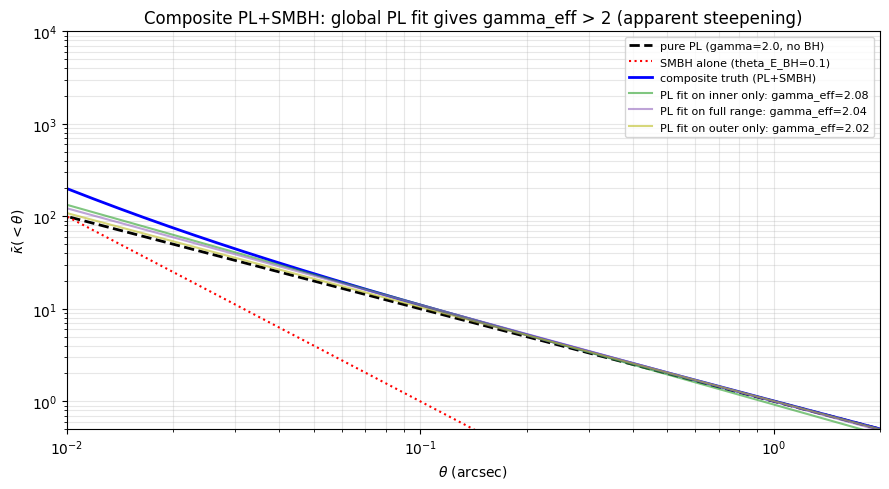


The SMBH STEEPENS the inner profile (kappa_BH falls as 1/r^2 vs
kappa_PL falling as 1/r for isothermal). When a global PL is fit:
  - inner-only sees the BH dominance and reports gamma_eff > 2 (steepest)
  - outer-only barely sees the BH, returning gamma_eff ~ truth
  - full range averages -> gamma_eff somewhere in between

The DEGENERACY: a pure-PL fit with gamma_eff > 2 and no BH gives
the SAME outer kbar(r) as a (gamma=2 + BH) truth. Without inner-region
data (JWST) or kinematics, you cannot distinguish these two models.


In [5]:
# Composite profile: power-law + SMBH point mass. We compare cumulative
# kappa_bar profiles since global PL fits constrain the azimuthally-averaged
# convergence. The SMBH adds kappa_bar_BH(r) = (theta_E_BH / r)^2.

def kappa_avg_pl(r, theta_E=1.0, gamma=2.0):
    """Mean convergence inside radius r for the power-law."""
    return (theta_E / r) ** (gamma - 1)

def kappa_avg_composite(r, theta_E=1.0, gamma=2.0, theta_E_BH=0.05):
    """Mean convergence for power-law + point mass (BH)."""
    return kappa_avg_pl(r, theta_E, gamma) + (theta_E_BH / r) ** 2

# Pedagogical demo: use an unrealistically-large BH (theta_E_BH = 0.1") so that
# the gamma_eff shift is visible at HST-resolvable scales (r > 0.05"). A real
# AGEL UMBH at 10^10.5 M_sun has theta_E_BH ~ 0.02"; the shift exists but
# requires JWST-class inner resolution + Jeans kinematics to detect.
theta_E_BH_demo = 0.1  # pedagogical, NOT physical
r = np.logspace(-2.5, 0.3, 200)  # 0.003 to 2 arcsec
kbar_truth = kappa_avg_composite(r, 1.0, 2.0, theta_E_BH_demo)

# Fit a pure power-law to kbar_truth (in log space). Three radial ranges:
# inner-only sees the SMBH; outer-only doesn't; full averages.
logr = np.log10(r); logk = np.log10(kbar_truth)
fits = {}
for label, rmin, rmax in [('inner only (0.05-0.3")', 0.05, 0.3),
                           ('full range (0.05-1.5")', 0.05, 1.5),
                           ('outer only (0.3-1.5")',  0.3,  1.5)]:
    mask = (r > rmin) & (r < rmax)
    p = np.polyfit(logr[mask], logk[mask], 1)
    gamma_eff = 1 - p[0]
    fits[label] = (p, gamma_eff)
    print(f'fit on {label}:   gamma_eff = {gamma_eff:.3f}   (truth gamma = 2.0)')

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(r, kappa_avg_pl(r, 1.0, 2.0), 'k--', lw=2, label='pure PL (gamma=2.0, no BH)')
ax.loglog(r, (theta_E_BH_demo / r)**2, 'r:', lw=1.5,
          label=f'SMBH alone (theta_E_BH={theta_E_BH_demo})')
ax.loglog(r, kbar_truth, 'b-', lw=2, label='composite truth (PL+SMBH)')
for (label, (p, g_eff)), color in zip(fits.items(), ['tab:green', 'tab:purple', 'tab:olive']):
    ax.loglog(r, 10**(p[1] + p[0]*np.log10(r)), color=color, lw=1.5, ls='-', alpha=0.6,
              label=f'PL fit on {label.split(" ")[0]+" "+label.split(" ")[1]}: gamma_eff={g_eff:.2f}')
ax.set_xlabel(r'$\theta$ (arcsec)'); ax.set_ylabel(r'$\bar\kappa(<\theta)$')
ax.set_title('Composite PL+SMBH: global PL fit gives gamma_eff > 2 (apparent steepening)')
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8)
ax.set_xlim(0.01, 2); ax.set_ylim(0.5, 1e4)
plt.tight_layout(); plt.show()

print('\nThe SMBH STEEPENS the inner profile (kappa_BH falls as 1/r^2 vs')
print('kappa_PL falling as 1/r for isothermal). When a global PL is fit:')
print('  - inner-only sees the BH dominance and reports gamma_eff > 2 (steepest)')
print('  - outer-only barely sees the BH, returning gamma_eff ~ truth')
print('  - full range averages -> gamma_eff somewhere in between')
print('\nThe DEGENERACY: a pure-PL fit with gamma_eff > 2 and no BH gives')
print('the SAME outer kbar(r) as a (gamma=2 + BH) truth. Without inner-region')
print('data (JWST) or kinematics, you cannot distinguish these two models.')

**The degeneracy.** A composite (power-law γ=2 + SMBH) and a pure (power-law γ′ < 2 with no SMBH) produce **near-identical lensing observables** at the resolution of HST imaging — the differences live below 0.05″ where neither model is observationally distinguishable. The integrated convergence inside the radial caustic, the radial-caustic radius, and the radial-arc magnification all are insensitive to whether the inner steep gradient is from a point mass or from a steeper power-law slope.

**What breaks the degeneracy.**

1. **Stellar kinematics** $\sigma_v(R)$ — integrates *different* radii than the lensing constraint. The Jeans equation links σ_v to the cumulative mass; a central point mass produces a divergent $\sigma_v$ at $R \to 0$ that an unresolved measurement still constrains via aperture averaging. **This is the primary handle.** Module 13 derives the anisotropic Jeans solution; `Examples/radial_arc_smbh/` applies it.
2. **Multi-source consistency** — if the lens has *two* sources at different impact parameters, both must trace through the same mass distribution. A composite vs pure-power-law fit gives different predictions for the second source's positions; a joint fit can distinguish them. The AGEL DSPL spirals exploit this when available.
3. **High-resolution central imaging** — JWST NIRCam diffraction-limited (~0.06″ at F200W) probes scales where the point-mass-vs-steep-PL difference is observable. The Shajib et al. paper uses JWST data for exactly this purpose.
4. **Time delays** — point-mass and steep-PL profiles produce different $D_{\Delta t}$ for the same observed $\Delta t$. TDCOSMO methodology breaks the degeneracy when delays are measurable.

*In v0.96 of this curriculum:* `Examples/radial_arc_smbh/` exercises method (1) — Jeans kinematic constraint — on a synthetic mock with a known M_BH = 10^10 M_sun truth. The before/after kinematic-break in the (γ′, M_BH) joint posterior is the headline demonstration.

## 5. Hand-off

**Where to go next:**

- **`Examples/radial_arc_smbh/`** (v0.96) — practical methodology bridge. Takes the theory from this module and builds a fittable synthetic Einstein-spiral mock with an explicit SMBH `al.mp.PointMass` component. Demonstrates:
  - Direct imaging fit (γ′ free, no BH) → posterior on apparent γ′
  - Add `al.mp.PointMass` → joint (γ′, M_BH) posterior with the §4 degeneracy visible
  - Add a synthetic σ_v Jeans likelihood → degeneracy broken, M_BH posterior tightened to truth
  - **Bridge to real AGEL targets:** explicit checklist of real-data systematics (empirical PSF, neighbor light, real σ_v pipeline, photometric redshifts, multi-band, inner-slope systematics budget).

- **Module 13 (TDCOSMO + Kinematics)** — the Jeans-equation theory the `with_kinematics` part of `radial_arc_smbh` consumes. Anisotropic Jeans + aperture-averaged σ_v projection.

- **Module 11 (Physical Mass Models)** — the 6-panel residual audit applies unchanged to the radial-arc fit. After running the `radial_arc_smbh` fit, audit its residuals using Module 11's framework.

- **AGEL paper references** — Shajib et al. *"An ultramassive black hole 7.1 Gyr ago in the first 'Einstein spiral' gravitational lens"* and Ferrami et al. *"Detection of a quiescent billion solar mass black hole at z≈0.7 with gravitational lensing"* (DESJ0206 ApJL). Both papers operationalise the methodology this module teaches.

- **`Examples/agel_real_target/`** (v0.97+) — the future depth-C step. Apply the `radial_arc_smbh` methodology to a real AGEL Einstein-spiral target with real HST+JWST data + IFU σ_v.

## Summary cheat sheet

1. The Jacobian $\mathcal{A}$ has two eigenvalues, $\lambda_t$ and $\lambda_r$. Tangential critical curve where $\lambda_t = 0$; radial critical curve where $\lambda_r = 0$.
2. The **radial caustic** $\beta_r(\gamma')$ scales with inner mass slope — that's how radial arcs constrain γ′.
3. Magnification asymptotics: $\mu \propto 1/d$ near tangential caustic, $\mu \propto 1/\sqrt d$ near radial caustic.
4. Adding a central SMBH to a power-law lens **shifts** the apparent global γ′ downward (sub-isothermal signature). This is the **γ′–M_BH degeneracy**.
5. **Kinematics breaks the degeneracy** — Jeans-equation σ_v aperture measurement separates point-mass contribution from steep-PL contribution. `Examples/radial_arc_smbh/` operationalises this.
6. Pure isothermal axisymmetric lenses have NO radial critical curve ($\lambda_r \equiv 1$). Radial arcs require either γ′ ≠ 2 or broken axisymmetry (ellipticity, shear).

---

*Learning to Autolens / Modules / 15 — Radial Arcs & Caustic Topology*  
*Rodrigo Córdova Rosado, Harvard CfA*